In [34]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering_invariant import AgglomerativeClustering
from utils import *
import sklearn.cluster as cluster
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
from scipy.special import gamma
from scipy.stats import multivariate_normal,f
import random

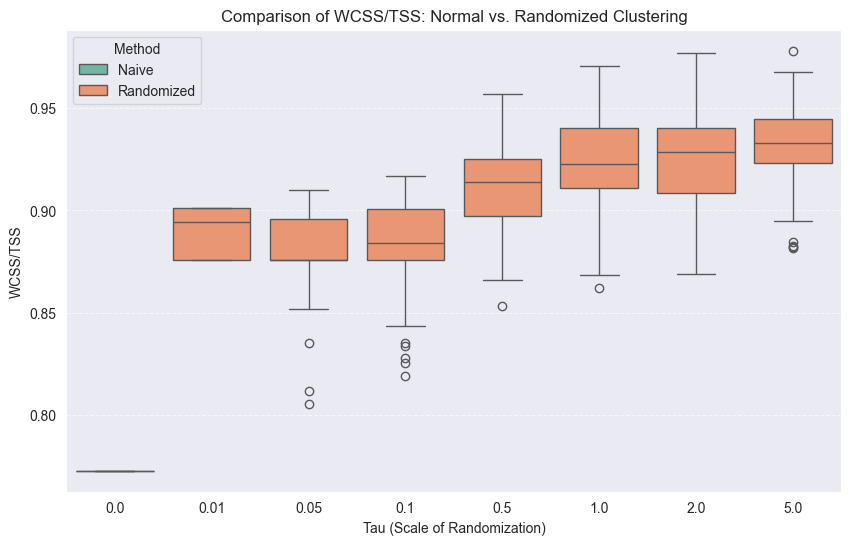

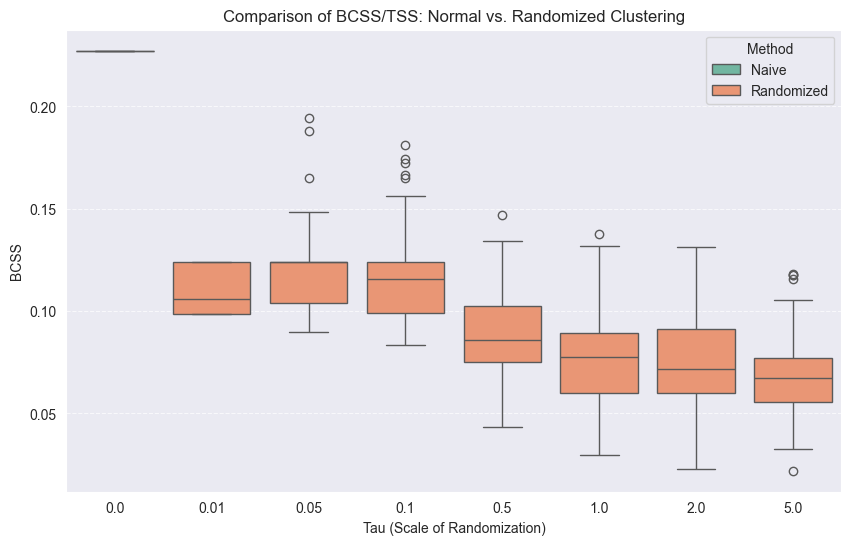

In [40]:
random.seed(10)
n = 30
p = 10
mu = np.zeros(p)
sigma = 1
tau_values = [0,0.01,0.05, 0.1,0.5,1,2,5]
n_runs = 100
n_clusters = 3
# Data collection
results = []
bcss = []
X = generate_null_data(n,p,mu,sigma)
for tau in tau_values:
    for _ in range(n_runs):
        #X, y = make_blobs(n_samples=n, centers=3, cluster_std=1)
        #X, y = generate_data_barbers(10,6,1)
        tss = np.sum((X - np.mean(X, axis=0)) ** 2)
        if tau != 0:
            # Randomized hierarchical clustering
            randomized_clustering = AgglomerativeClustering(X, n_clusters=n_clusters, tau=tau)
            randomized_clustering.fit()
            randomized_score = randomized_clustering.compute_wcss()
            bcss_score = randomized_clustering.compute_bcss()
            results.append({'Tau': tau, 'Method': 'Randomized', 'WCSS/TSS': randomized_score / tss})
            bcss.append({'Tau': tau, 'Method': 'Randomized', 'BCSS/TSS': bcss_score / tss})
        else:
            naive = cluster.AgglomerativeClustering(n_clusters=n_clusters)
            naive_labels = naive.fit_predict(X)
            naive_score = 0
            for k in range(n_clusters):
                cluster_points = X[naive_labels == k]
                if len(cluster_points) > 0:
                    center = np.mean(cluster_points, axis=0)
                    naive_score += np.sum((cluster_points - center) ** 2)
            results.append({'Tau': tau, 'Method': "Naive", 'WCSS/TSS': naive_score / tss})
            bcss.append({'Tau': tau, 'Method': "Naive", 'BCSS/TSS': (tss - naive_score) / tss})

# Convert results to a DataFrame
df = pd.DataFrame(results)
df_bcss = pd.DataFrame(bcss)

# Create side-by-side boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Tau', y='WCSS/TSS', hue='Method', palette='Set2')
plt.title('Comparison of WCSS/TSS: Normal vs. Randomized Clustering')
plt.xlabel('Tau (Scale of Randomization)')
plt.ylabel('WCSS/TSS')
plt.legend(title='Method',loc = 'upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_bcss, x='Tau', y='BCSS/TSS', hue='Method', palette='Set2')
plt.title('Comparison of BCSS/TSS: Normal vs. Randomized Clustering')
plt.xlabel('Tau (Scale of Randomization)')
plt.ylabel('BCSS')
plt.legend(title='Method',loc = 'upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [41]:
med = (
    df.groupby(['Tau','Method'])['WCSS/TSS']
      .median()
      .unstack('Method')
      .rename(columns={'Naive':'Naive_median','Randomized':'Rand_median'})
      .reset_index()
      .sort_values('Tau')
)
rand_curve = (
    med.loc[med['Tau']>0, ['Tau','Rand_median']]
    .copy()
    .sort_values('Tau')
)

taus = rand_curve['Tau'].to_numpy()
ys   = rand_curve['Rand_median'].to_numpy()

def pick_tau_by_max_adjacent_gap(taus, ys):
    gaps = np.abs(np.diff(ys))
    idx = np.argmax(gaps)
    return taus[idx], {'gap': float(gaps[idx])}
def pick_tau_by_second_difference(taus, ys):
    taus = np.asarray(taus, dtype=float)
    ys   = np.asarray(ys, dtype=float)
    second_diff = []
    for j in range(1, len(taus)-1):
        h1 = taus[j] - taus[j-1]
        h2 = taus[j+1] - taus[j]

        val = (ys[j-1] - 2*ys[j] + ys[j+1]) / ((0.5*(h1+h2))**2)
        second_diff.append(val)

    second_diff = np.array(second_diff)
    idx = np.argmax(np.abs(second_diff)) + 1 

    return taus[idx], {"second_diff": float(second_diff[idx-1])}
#tau_gap, info_gap = pick_tau_by_max_adjacent_gap(taus, ys)
tau_elbow, info_elbow = pick_tau_by_second_difference(taus, ys)
print(f"τ* = {tau_elbow}, second_diff = {info_elbow['second_diff']:.4f}")

τ* = 0.05, second_diff = 13.2469


1e-05 18.337112421479116
1e-05 10.725146609339912
1e-05 19.290902745213216
1e-05 13.98840285472144
1e-05 10.381368977070903
1e-05 15.87845642893919
1e-05 14.594156928485436
1e-05 16.243975924666827
1e-05 11.13136819711789
1e-05 10.807989319815858
1e-05 16.268075872124456
1e-05 14.114726675357009
1e-05 13.246401949624971
1e-05 18.063592407550303
1e-05 10.800432139452312
1e-05 15.99877464342775
1e-05 19.453687744596238
1e-05 13.082384506487893
1e-05 10.73265641435163
1e-05 11.038319263850893
1e-05 12.497602170491062
1e-05 14.215494670730514
1e-05 13.701482575642409
1e-05 10.76926755701552
1e-05 15.337600760848538
1e-05 11.02852136859834
1e-05 15.95053228886481
1e-05 10.798152412229568
1e-05 14.255719683166763
1e-05 15.474547992444059
1e-05 14.129018096611443
1e-05 14.626853888144526
1e-05 12.91834263384747
1e-05 14.383108865503626
1e-05 10.892375034426447
1e-05 15.19529793470429
1e-05 10.868648593014179
1e-05 14.191989850361722
1e-05 13.46082645928718
1e-05 16.61765613909921
1e-05 21.357

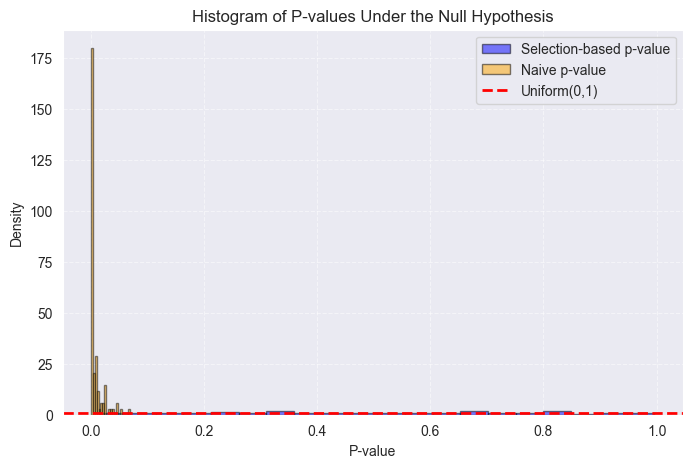

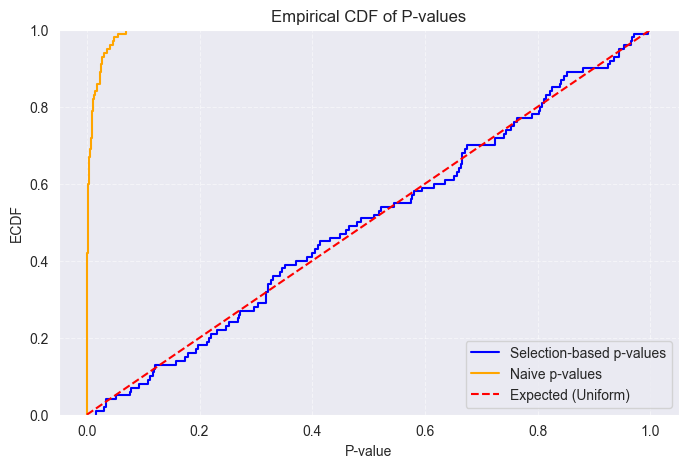

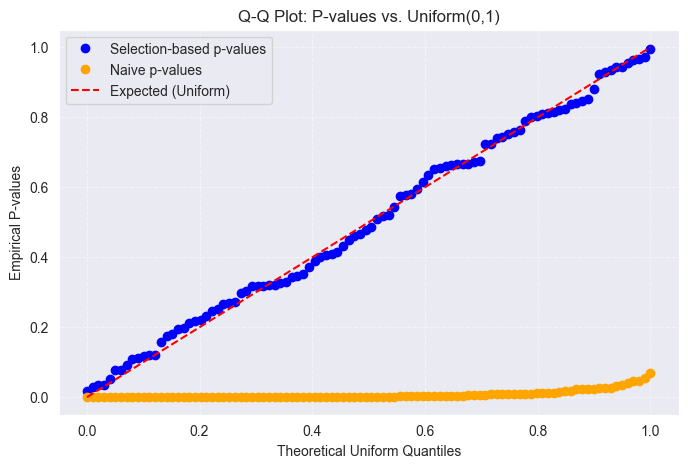

In [42]:
check_p_value_uniformity(n,p,sigma,n_clusters,tau_elbow,-1,num_trials=100)

In [43]:
def check_p_value_uniformity_sameX(X, n, p, sigma, K, tau, layer, linkage="complete", num_trials=100):
    p_values = []
    p_values_n = []
    mu = np.zeros(p)
    while len(p_values_n) < num_trials:
        model = AgglomerativeClustering(X, tau=tau, n_clusters=K, linkage=linkage)
        model.fit()

        c1 = model.K_clusters[0]
        c2 = model.K_clusters[1]
        p_value, obs, sel_corrected = model.merge_inference_F_random_pair_grid(c1,c2, grid_width = 150, ncoarse=30, ngrid=2000)
        p_value_n = naive_p_value(X, K, layer, linkage)
        if not (np.isnan(p_value) and np.isnan(p_value_n)):
            p_values.append(p_value)
            p_values_n.append(p_value_n)
    p_values = np.array(p_values)
    p_values_n = np.array(p_values_n)

    # Histogram for both p-values
    plt.figure(figsize=(8, 5))
    plt.hist(p_values, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black",
             label="Selection-based p-value")
    plt.hist(p_values_n, bins=20, density=True, alpha=0.5, color="orange", edgecolor="black", label="Naive p-value")
    plt.axhline(1, color='red', linestyle='dashed', linewidth=2, label="Uniform(0,1)")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of P-values Under the Null Hypothesis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.ecdfplot(p_values, color="blue", label="Selection-based p-values")
    sns.ecdfplot(p_values_n, color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("P-value")
    plt.ylabel("ECDF")
    plt.title("Empirical CDF of P-values")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Q-Q Plot for both p-values
    plt.figure(figsize=(8, 5))
    sorted_p_values = np.sort(p_values)
    sorted_p_values_n = np.sort(p_values_n)
    theoretical_quantiles = np.linspace(0, 1, num_trials)

    plt.plot(theoretical_quantiles, sorted_p_values, marker='o', linestyle='', color="blue",
             label="Selection-based p-values")
    plt.plot(theoretical_quantiles, sorted_p_values_n, marker='o', linestyle='', color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


1e-05 19.67166495637328
1e-05 15.017564230728155
1e-05 18.673935786127032
1e-05 22.083908084749623
1e-05 19.36700748323576
1e-05 21.37156310108974
1e-05 18.32595632391688
1e-05 16.785810664418268
1e-05 17.21180233853065
1e-05 16.53763559900011
1e-05 17.13233557014904
1e-05 17.19345409238106
1e-05 14.89863937128396
1e-05 14.417354416650806
1e-05 17.66500476855291
1e-05 19.00384879314602
1e-05 18.92844950957077
1e-05 17.661109642084917
1e-05 18.16312734933191
1e-05 19.456961543706583
1e-05 20.230019308478276
1e-05 14.82915111470374
1e-05 20.06956491663612
1e-05 17.744322300214066
1e-05 19.55853413026631
1e-05 15.114379743903097
1e-05 19.781405509604802
1e-05 15.051131765166282
1e-05 14.70452058573207
1e-05 16.349621775600692
1e-05 19.478034342855757
1e-05 18.74738535050621
1e-05 17.118801697993863
1e-05 19.980425175395567
1e-05 18.281118425582054
1e-05 18.61905998475508
1e-05 16.544230015652833
1e-05 18.116430542418065
1e-05 17.981012335444234
1e-05 15.780004425810446
1e-05 20.0558478873

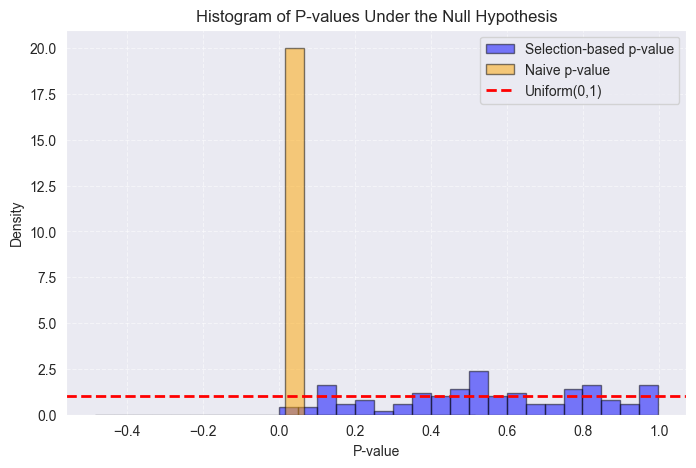

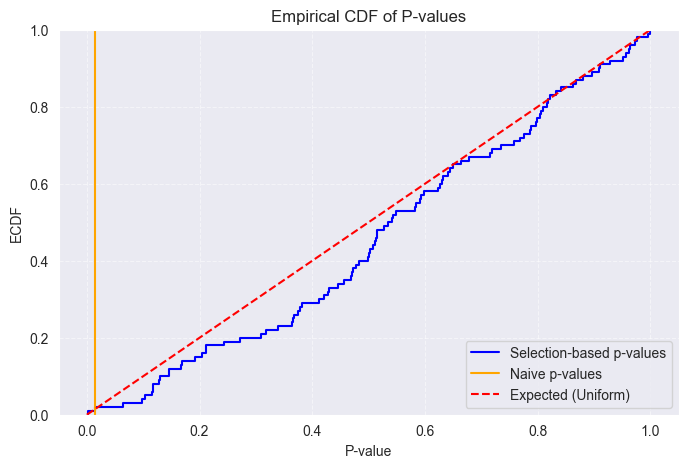

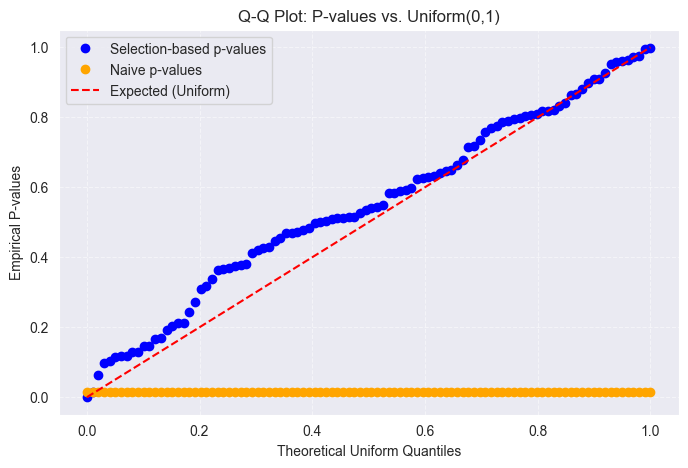

In [44]:
check_p_value_uniformity_sameX(X,n,p,sigma,n_clusters,tau_elbow,-1)